# Module 3 — Explainable AI

**DesignSafe AI Training**

[![Try on DesignSafe](https://raw.githubusercontent.com/DesignSafe-CI/training-ai/main/DesignSafe-Badge.svg)](https://jupyter.designsafe-ci.org/hub/user-redirect/lab/tree/CommunityData/Training/2026-SPARC/Day3/3b-SciML/03-xai-lateral-spreading.ipynb) [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DesignSafe-CI/training-ai/blob/main/03-xai/03-xai-lateral-spreading.ipynb)

---

## An MLP trades three readable exponents for thousands of weights

Module 2 ended on an uncomfortable trade. The linear model in log space gave us
three numbers — `0.5`, `1.5`, `-0.5` — that *were* the physics. The MLP matched
it without being told anything, and handed back a few thousand weights that mean
nothing to anyone.

For a cantilever we could check the answer against a closed form. On a real
dataset there is no closed form to check against, and "the network said so" is
not an answer you can put in a report or defend to a reviewer.

This module is about getting the interpretation back.

## Lateral spreading, from 7,291 field observations

Lateral spreading — the down-slope movement of liquefied ground during an
earthquake. It wrecks pipelines, bridge abutments, and quay walls. We have 7,291
field observations, each labelled *did* or *did not* spread, with four
predictors.

<img src="figs/liquefaction.png" width="700"/>



| 5 | From local attributions to global structure |

## Setup

In [1]:
%pip install scikit-learn pandas xgboost shap matplotlib --quiet

/private/tmp/claude-501/-Users-krishna-dev-DesignSafe-Training/a3c591bf-7af0-4642-a72e-3ed72e972147/scratchpad/venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = 42
np.random.seed(RNG)
plt.rcParams.update({"figure.figsize": (10, 4.5), "font.size": 11})


def find_data(name):
    """Locate a data file whether we are on DesignSafe, Colab, or a laptop."""
    here = Path.cwd()
    for c in [Path("/home/jupyter/CommunityData/Training/2026-SPARC/Day3/3b-SciML") / name, here / name,
              here / "03-xai" / name, here.parent / name]:
        if c.exists():
            return c
    url = ("https://raw.githubusercontent.com/DesignSafe-CI/training-ai"
           f"/main/03-xai/{name}")
    print(f"Not found locally, downloading from {url}")
    return url

## Four predictors survive; two are dropped

The raw file has six columns plus the label. We keep **four** as predictors.

| Column | Meaning | Why it might matter |
| --- | --- | --- |
| `GWD (m)` | Groundwater depth | Liquefaction needs saturated soil; a deeper water table means less susceptible material |
| `L (km)` | Distance to the free face | Spreading needs somewhere to go — a channel, a shoreline |
| `Slope (%)` | Ground slope | The driving force for down-slope movement |
| `PGA (g)` | Peak ground acceleration | The demand: how hard the ground shook |
| ~~`Elevation`~~ | Elevation | **Dropped** — largely redundant with the slope and free-face geometry |
| ~~`Test ID`~~ | Record identifier | **Dropped** — an index, not a predictor. Leaving an ID in is a classic leakage bug |
| `Target` | 1 = spreading observed, 0 = not | The label |

<img src="figs/liq-factors.png" width="720"/>

In [3]:
df = pd.read_csv(find_data("RF_YN_Model3.csv"))
print(f"{len(df)} observations")
df.head()

7291 observations


,Test ID,GWD (m),Elevation,L (km),Slope (%),PGA (g),Target
0,182,0.370809,0.909116,0.319117,5.465739,0.546270,0
1,15635,1.300896,1.123009,0.211770,0.905948,0.532398,0
2,8292,1.300896,0.847858,0.195947,0.849104,0.532398,0
3,15629,1.788212,2.044325,0.115795,0.451034,0.542307,0
4,183,1.637517,2.003797,0.137265,0.941866,0.545784,1


In [4]:
df = df.drop(["Test ID", "Elevation"], axis=1)

features = [c for c in df.columns if c != "Target"]
X = df[features]
y = df["Target"]

print(f"{len(features)} predictors: {features}")

print("class balance:")
print(f"  no spreading (0):  {(y == 0).sum():>5d}   ({(y == 0).mean():.1%})")
print(f"  spreading    (1):  {(y == 1).sum():>5d}   ({(y == 1).mean():.1%})")
print("\nReasonably balanced, so plain accuracy is a fair headline metric.")
df.describe().T[["mean", "std", "min", "max"]]

4 predictors: ['GWD (m)', 'L (km)', 'Slope (%)', 'PGA (g)']
class balance:
  no spreading (0):   4236   (58.1%)
  spreading    (1):   3055   (41.9%)

Reasonably balanced, so plain accuracy is a fair headline metric.


,mean,std,min,max
GWD (m),2.075960,0.641597,0.370809,6.047182
L (km),1.018893,0.646159,0.000000,3.289537
Slope (%),1.139434,1.133215,0.000000,10.922902
PGA (g),0.439751,0.042140,0.328797,0.567631
Target,0.419010,0.493431,0.000000,1.000000


### Tune on validation; touch the test set once

Train / validation / test. The validation set is what you tune against; the test
set you touch **once**, at the end. Two calls to `train_test_split` give us the
three-way split.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_hold, y_train, y_hold = train_test_split(
    X, y, test_size=0.3, random_state=RNG, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_hold, y_hold, test_size=0.5, random_state=RNG, stratify=y_hold)

for name, part in (("train", y_train), ("val", y_val), ("test", y_test)):
    print(f"  {name:>5s}  {len(part):>5d} rows   {part.mean():.1%} positive")

  train   5103 rows   41.9% positive
    val   1094 rows   42.0% positive
   test   1094 rows   41.9% positive


## Part 1 — The decision tree: a model you can read

A decision tree asks a sequence of threshold questions. At each node it picks the
split that most reduces **Gini impurity**,

$$G = 1 - \sum_k p_k^2$$

which is 0 for a pure node (all one class) and 0.5 for a 50/50 mix in a binary
problem. The tree greedily searches every feature and every threshold for the
split with the largest weighted drop in $G$.

<img src="figs/decision-tree-rf.png" width="700"/>

Start shallow, so we can print the whole thing.

In [6]:
from sklearn import tree
from sklearn.metrics import accuracy_score

dt = tree.DecisionTreeClassifier(max_depth=3, random_state=RNG).fit(X_train, y_train)

print(f"  train {dt.score(X_train, y_train):.1%}")
print(f"  val   {dt.score(X_val, y_val):.1%}")

  train 68.2%
  val   68.9%


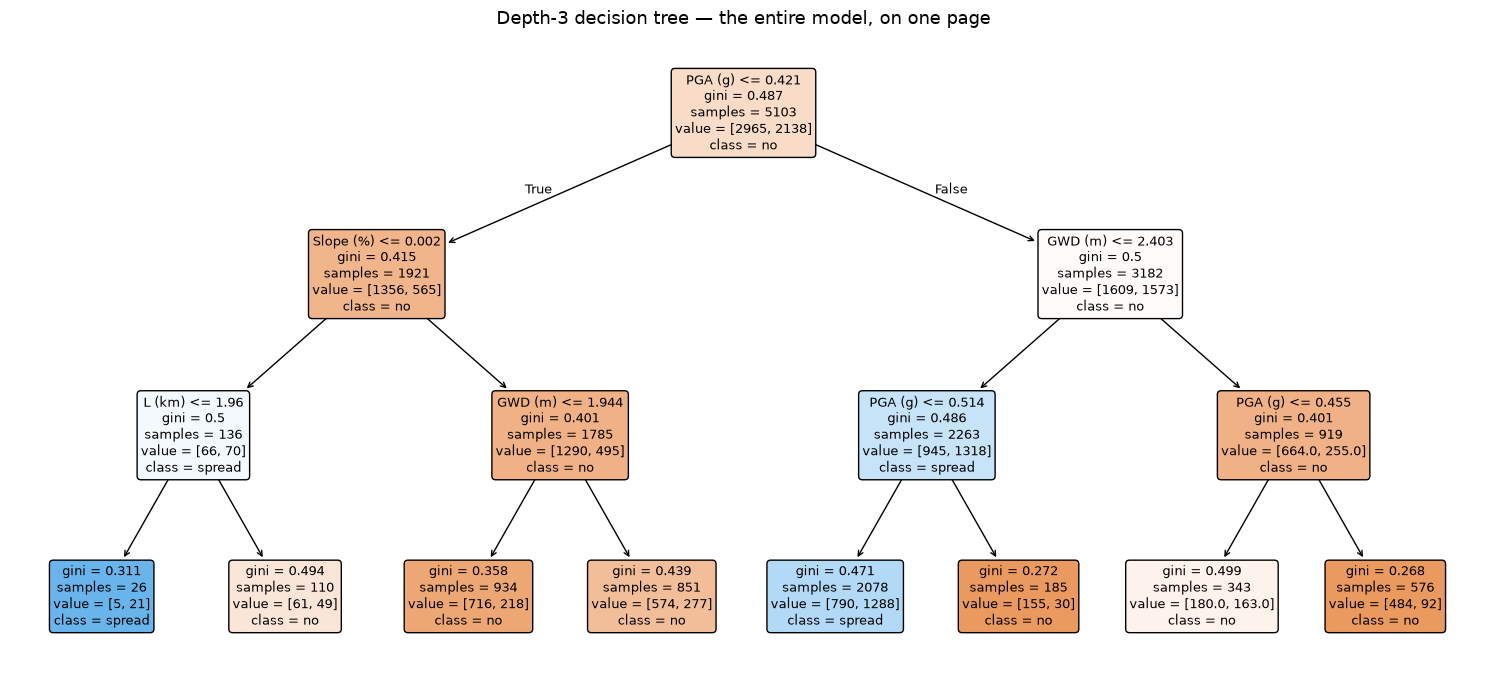

In [7]:
fig, ax = plt.subplots(figsize=(15, 7))
tree.plot_tree(dt, feature_names=features, class_names=["no", "spread"],
               filled=True, rounded=True, fontsize=9, impurity=True, ax=ax)
plt.title("Depth-3 decision tree — the entire model, on one page")
plt.tight_layout()
plt.show()

**This is the baseline that XAI is trying to get back to.** You can read
the root split straight off the figure, hand the diagram to a geotechnical
engineer, and have an argument about whether the thresholds are sensible. No
attribution method needed — the model *is* its own explanation.

Now watch what we give up to gain accuracy.

max_depth  leaves  train   val
        1       2  58.1% 58.0%
        2       4  65.5% 65.8%
        3       8  68.2% 68.9%
        5      30  70.8% 71.0%
        7      93  78.2% 73.5%
        9     211  83.0% 74.9%
       12     422  90.9% 77.7%
       15     645  96.8% 79.4%
     None     808 100.0% 79.7%


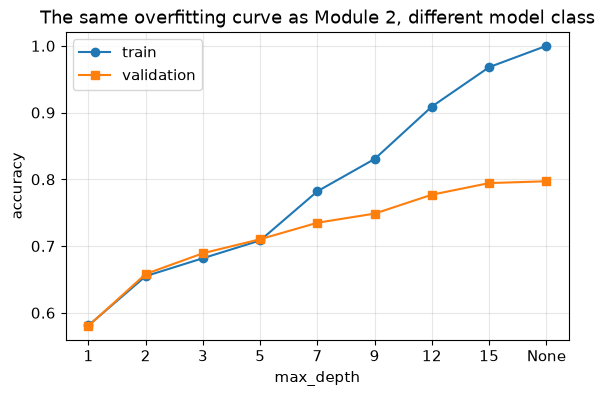

In [8]:
depths = [1, 2, 3, 5, 7, 9, 12, 15, None]
rows = []
for d in depths:
    m = tree.DecisionTreeClassifier(max_depth=d, random_state=RNG).fit(X_train, y_train)
    rows.append({"max_depth": str(d), "leaves": m.get_n_leaves(),
                 "train": m.score(X_train, y_train), "val": m.score(X_val, y_val)})

depth_df = pd.DataFrame(rows)
print(depth_df.to_string(index=False,
      formatters={"train": "{:.1%}".format, "val": "{:.1%}".format}))

plt.figure(figsize=(6.5, 4))
plt.plot(range(len(depths)), depth_df["train"], "o-", label="train")
plt.plot(range(len(depths)), depth_df["val"], "s-", label="validation")
plt.xticks(range(len(depths)), depth_df["max_depth"])
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("The same overfitting curve as Module 2, different model class")
plt.legend(); plt.grid(alpha=.3); plt.show()

Deeper trees memorise: training accuracy runs to 100% while validation
accuracy peaks and then decays. Exactly the gap we opened with the width-256 MLP
in Module 2 — overfitting is a property of *capacity versus data*, not of neural
networks specifically.

By `max_depth=15` the tree has hundreds of leaves. It is still technically
"readable", in the sense that a phone book is readable.

## Part 2 — Gradient boosting: accuracy at the cost of legibility

One tree is a weak learner. **Boosting** fits a sequence of trees where each new
tree is trained on the *residual errors* of the ensemble so far:

$$F_{m}(x) = F_{m-1}(x) + \eta\, h_m(x), \qquad
h_m \approx -\frac{\partial \mathcal{L}}{\partial F_{m-1}}$$

That is gradient descent, but in *function space* — each tree is a step along the
negative gradient of the loss. XGBoost adds second-order (Newton) information, an
$L^2$ penalty on leaf weights, shrinkage, and column subsampling.

<img src="figs/xgb.png" width="700"/>

In [9]:
import xgboost

xgb = xgboost.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", random_state=RNG,
).fit(X_train, y_train)

best_dt = tree.DecisionTreeClassifier(max_depth=7, random_state=RNG).fit(X_train, y_train)

print(f"{'model':<28s} {'train':>8s} {'val':>8s}")
print(f"{'decision tree (depth 3)':<28s} {dt.score(X_train,y_train):>7.1%} {dt.score(X_val,y_val):>8.1%}")
print(f"{'decision tree (depth 7)':<28s} {best_dt.score(X_train,y_train):>7.1%} {best_dt.score(X_val,y_val):>8.1%}")
print(f"{'XGBoost (400 trees)':<28s} {xgb.score(X_train,y_train):>7.1%} {xgb.score(X_val,y_val):>8.1%}")
print(f"\nThe ensemble contains {400 * 1} trees. Good luck reading it.")

model                           train      val
decision tree (depth 3)        68.2%    68.9%
decision tree (depth 7)        78.2%    73.5%
XGBoost (400 trees)            86.0%    78.3%

The ensemble contains 400 trees. Good luck reading it.


A few points of accuracy, bought with 400 trees. The model is now a black
box in exactly the way the Module 2 MLP was: it works, and it cannot tell you
why.

That is the setup for the rest of the module.

## Part 3 — Feature importance, and why the number depends on who you ask

"Which features matter?" sounds like one question. It is at least three, and they
do not have to agree.

| Definition | What it counts | Failure mode |
| --- | --- | --- |
| **Weight / frequency** | How many times a feature is split on | Favours high-cardinality continuous features — they offer more thresholds to try |
| **Gain** | Total impurity reduction credited to the feature | Biased toward features used near the root |
| **Permutation** | Accuracy lost when you shuffle that column | Model-agnostic and honest, but misleading under correlated features |

The first two are free (they fall out of the fitted trees). The third costs a
re-evaluation per feature but measures something you actually care about:
*predictive* contribution.

In [10]:
from sklearn.inspection import permutation_importance

gain = xgb.get_booster().get_score(importance_type="gain")
weight = xgb.get_booster().get_score(importance_type="weight")

perm = permutation_importance(xgb, X_val, y_val, n_repeats=10,
                             random_state=RNG, scoring="accuracy")

imp = pd.DataFrame({
    "weight": [weight.get(f, 0) for f in features],
    "gain": [gain.get(f, 0) for f in features],
    "permutation": perm.importances_mean,
}, index=features)

# Normalise each column to fractions so the three are comparable.
imp_n = imp / imp.sum()
print("Feature importance, each column normalised to sum to 1:\n")
print(imp_n.to_string(float_format="{:.3f}".format))

print("\nRanking by each definition:")
for col in imp_n.columns:
    order = " > ".join(imp_n[col].sort_values(ascending=False).index)
    print(f"  {col:>12s}:  {order}")

Feature importance, each column normalised to sum to 1:

           weight  gain  permutation
GWD (m)     0.229 0.255        0.231
L (km)      0.278 0.274        0.335
Slope (%)   0.167 0.143        0.026
PGA (g)     0.326 0.328        0.408

Ranking by each definition:
        weight:  PGA (g) > L (km) > GWD (m) > Slope (%)
          gain:  PGA (g) > L (km) > GWD (m) > Slope (%)
   permutation:  PGA (g) > L (km) > GWD (m) > Slope (%)


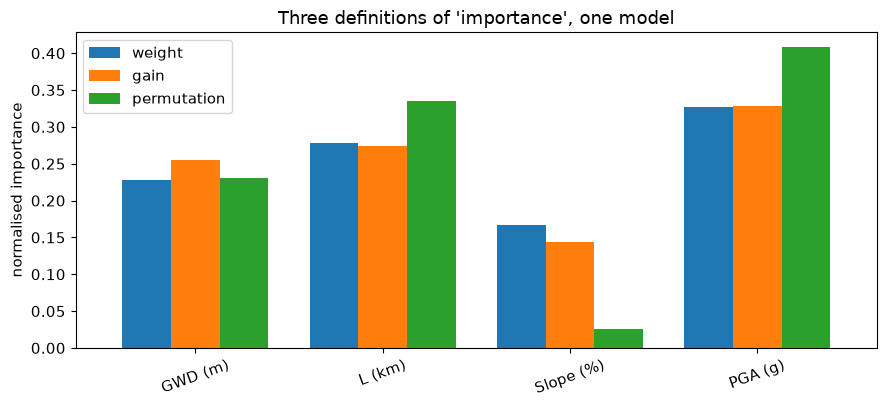

In [11]:
ax = imp_n.plot.bar(figsize=(9, 4.2), rot=20, width=.78)
ax.set_ylabel("normalised importance")
ax.set_title("Three definitions of 'importance', one model")
ax.legend(title=None)
plt.tight_layout(); plt.show()

### The three definitions agree on rank and differ 5x on slope

Good news first: **all three definitions produce the same ranking** here —
PGA, then distance to the free face, then groundwater depth, then slope. When
that happens it is genuine reassurance, and worth reporting.

Now look at the magnitudes, where they part company badly.

**Slope** is worth about 14-17% by gain and weight, and about **2-3% by
permutation** — a factor of five or six. The tree splits on slope frequently and
collects impurity reduction when it does, yet shuffling the slope column barely
dents accuracy.

That combination is not a contradiction; it is a **diagnosis**. It is the
signature of a feature whose information is already available elsewhere. Gain
answers "does the model use this?" — yes. Permutation answers "does the model
*need* this?" — apparently not, because when slope is destroyed the other
features cover for it.

Which is exactly what you would expect physically: slope, elevation, and distance
to a free face all describe the same site geometry. We dropped `Elevation` at the
start for that reason; the residual redundancy between slope and free-face
distance is still in there.

So the practical rules are:

- **Say which definition you used.** "Feature importance" alone is not a number.
- **A gain/permutation mismatch means redundancy**, not noise. Do not conclude
  "slope does not matter for lateral spreading" — it matters physically, and the
  model has simply found other routes to the same information.
- **Permutation importance is unreliable under correlated features** for precisely
  this reason: it asks what happens when one feature is destroyed *while its
  correlates stay intact*.

There is a further limitation that no column here escapes: all three are **global**
statements about the model averaged over 7,291 sites. None can tell you why *this*
site, with *these* four values, was flagged — which is the question an engineer
assessing a specific site actually has.

## Part 4 — SHAP: attributing one prediction

SHAP borrows the **Shapley value** from cooperative game theory (Shapley, 1953).

### Shapley values split credit over every joining order

Three engineers finish a project worth \$100k. How much of the credit belongs to
each? Shapley's answer: consider every possible order in which they could have
joined the project. For each ordering, record how much the value went up when a
given person joined. Average that marginal contribution over all orderings.

Swap "engineer" for "feature" and "project value" for "model output":

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}}
\frac{|S|!\,(|F| - |S| - 1)!}{|F|!}
\bigl[f(S \cup \{i\}) - f(S)\bigr]$$

$\phi_i$ is the contribution of feature $i$ to *this one prediction*, averaged
over every subset $S$ of the other features.

<img src="figs/shap.png" width="700"/>

### Efficiency, symmetry and dummy pin down one answer

Shapley values are the **unique** attribution satisfying three axioms:

- **Efficiency** — the attributions sum exactly to the prediction minus the
  baseline: $\sum_i \phi_i = f(x) - \mathbb{E}[f]$. Nothing is lost or invented.
- **Symmetry** — two features that always contribute identically get equal credit.
- **Dummy** — a feature that never changes the output gets exactly zero.

No other attribution method has all three. The catch is cost: the sum runs over
$2^{|F|}$ subsets. `TreeSHAP` exploits tree structure to compute it exactly in
polynomial time, which is why SHAP and gradient boosting are so often paired.

In [12]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

print(f"shap_values.values shape: {shap_values.values.shape}   (rows x features)")
print(f"baseline E[f(x)]        : {shap_values.base_values[0]:+.4f}  (log-odds)")
print("\nEfficiency check on the first 5 rows — attributions must sum to f(x) - E[f]:")
margin = xgb.predict(X_test, output_margin=True)
for i in range(5):
    lhs = shap_values.values[i].sum()
    rhs = margin[i] - shap_values.base_values[i]
    print(f"  row {i}:  sum(phi) = {lhs:+.5f}   f(x)-E[f] = {rhs:+.5f}   "
          f"diff {abs(lhs - rhs):.2e}")

shap_values.values shape: (1094, 4)   (rows x features)
baseline E[f(x)]        : -0.3301  (log-odds)

Efficiency check on the first 5 rows — attributions must sum to f(x) - E[f]:
  row 0:  sum(phi) = +0.87078   f(x)-E[f] = +0.87078   diff 5.96e-08
  row 1:  sum(phi) = +0.95742   f(x)-E[f] = +0.95742   diff 1.19e-07
  row 2:  sum(phi) = +0.47126   f(x)-E[f] = +0.47126   diff 2.98e-08
  row 3:  sum(phi) = -1.44210   f(x)-E[f] = -1.44210   diff 7.15e-07
  row 4:  sum(phi) = -0.83632   f(x)-E[f] = -0.83632   diff 5.96e-07


/private/tmp/claude-501/-Users-krishna-dev-DesignSafe-Training/a3c591bf-7af0-4642-a72e-3ed72e972147/scratchpad/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The attributions sum to the prediction, to machine precision. That is the
efficiency axiom, verified — and the reason SHAP can be defended in a way that
"gain" cannot.

### One site, decomposed: why this one spreads

The waterfall plot starts at the baseline $\mathbb{E}[f]$ and adds one feature at
a time until it reaches this site's prediction.

Most confident SPREAD  : row 102, p = 0.987
GWD (m)      1.027148
L (km)       0.019104
Slope (%)    1.618521
PGA (g)      0.436892


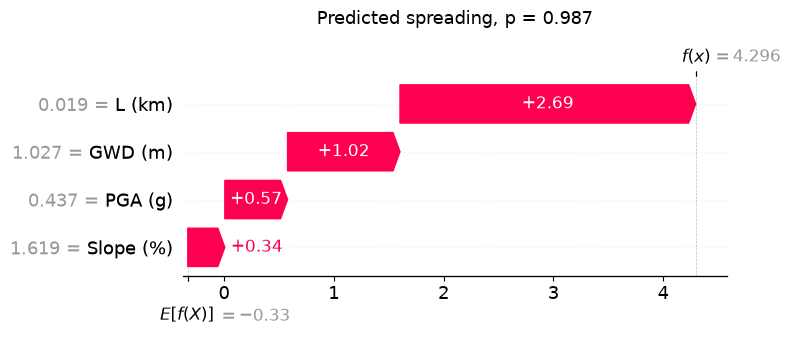

In [13]:
proba = xgb.predict_proba(X_test)[:, 1]
i_pos = int(np.argmax(proba))
i_neg = int(np.argmin(proba))

print(f"Most confident SPREAD  : row {i_pos}, p = {proba[i_pos]:.3f}")
print(X_test.iloc[i_pos].to_string())

shap.plots.waterfall(shap_values[i_pos], max_display=len(features) + 1, show=False)
plt.title(f"Predicted spreading, p = {proba[i_pos]:.3f}", pad=18)
plt.tight_layout(); plt.show()

Red bars push toward spreading, blue bars push away. The bar lengths are
in log-odds and they add up to the gap between the baseline and this
prediction.

### The same machinery, opposite conclusion

Same model, same machinery, opposite conclusion — and you can see *which*
features did the work.

Most confident NO SPREAD: row 357, p = 0.010
GWD (m)      1.862229
L (km)       2.658382
Slope (%)    0.549205
PGA (g)      0.367333


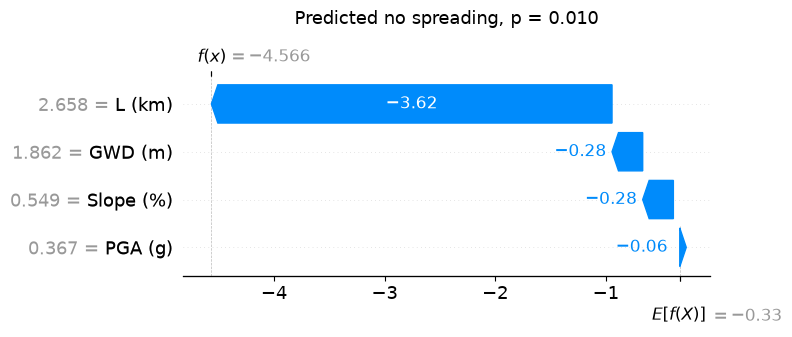

In [14]:
print(f"Most confident NO SPREAD: row {i_neg}, p = {proba[i_neg]:.3f}")
print(X_test.iloc[i_neg].to_string())

shap.plots.waterfall(shap_values[i_neg], max_display=len(features) + 1, show=False)
plt.title(f"Predicted no spreading, p = {proba[i_neg]:.3f}", pad=18)
plt.tight_layout(); plt.show()

## Part 5 — From local attributions to global structure

Compute SHAP values for every row and you can rebuild a global picture — but one
that keeps the per-site detail instead of averaging it away.

The **beeswarm** plot puts one dot per site per feature. Horizontal position is
that site's SHAP value; colour is the feature's value.

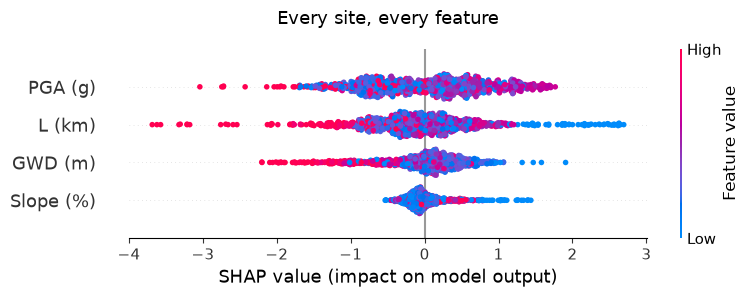

In [15]:
shap.plots.beeswarm(shap_values, max_display=len(features), show=False)
plt.title("Every site, every feature", pad=18)
plt.tight_layout(); plt.show()

Read it as: *does high (red) push right or left?* A clean red-right /
blue-left separation means a monotone effect and the colour tells you the sign.

This is where the physics check happens. Confirm each direction against what you
know:

- **Slope** — steeper ground should spread more readily. Higher slope pushing
  right is physically correct.
- **PGA** — stronger shaking, more liquefaction. Higher PGA pushing right is
  correct.
- **GWD** — a *deeper* water table means less saturated material in the critical
  zone, so higher GWD should push *left*.
- **L** — further from a free face means less room to move, so higher L should
  push *left*.

**If a direction comes out backwards, you have found something.** Either a data
problem (sign convention, units, a leaking column) or a genuine interaction the
model is capturing through a proxy. Either way it is worth chasing before the
model goes anywhere near a decision. This is the single most valuable thing XAI
does — not "explaining" a model that is right, but *catching* one that is wrong
for the right-looking reasons.

### Dependence plots locate the triggering threshold

A dependence plot shows SHAP value against feature value for one feature —
the shape of the learned response, including any threshold.

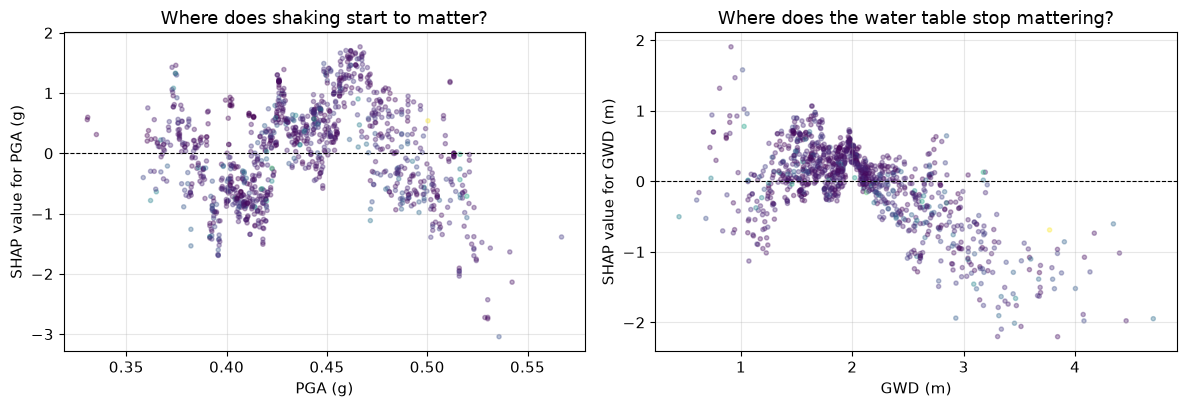

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, feat in zip(axes, ["PGA (g)", "GWD (m)"]):
    ax.scatter(X_test[feat], shap_values.values[:, features.index(feat)],
               s=9, alpha=.35, c=X_test["Slope (%)"], cmap="viridis")
    ax.axhline(0, color="k", lw=.8, ls="--")
    ax.set(xlabel=feat, ylabel=f"SHAP value for {feat}")
    ax.grid(alpha=.3)
axes[0].set_title("Where does shaking start to matter?")
axes[1].set_title("Where does the water table stop mattering?")
plt.tight_layout(); plt.show()

The crossing point — where the SHAP value passes through zero — is the
value at which this feature flips from suppressing to promoting spreading. That
is a *threshold learned from data*, directly comparable to the triggering curves
in the literature. The vertical spread at fixed $x$ is interaction with the other
features (coloured here by slope).

### optional — comparing the two models' explanations

The depth-3 tree and the 400-tree ensemble reach similar conclusions by
different routes. Comparing their global SHAP magnitudes is a useful sanity
check: large disagreement means the extra accuracy came from somewhere
you should understand before trusting it.

decision tree SHAP shape : (1094, 4, 2)
XGBoost SHAP shape       : (1094, 4)


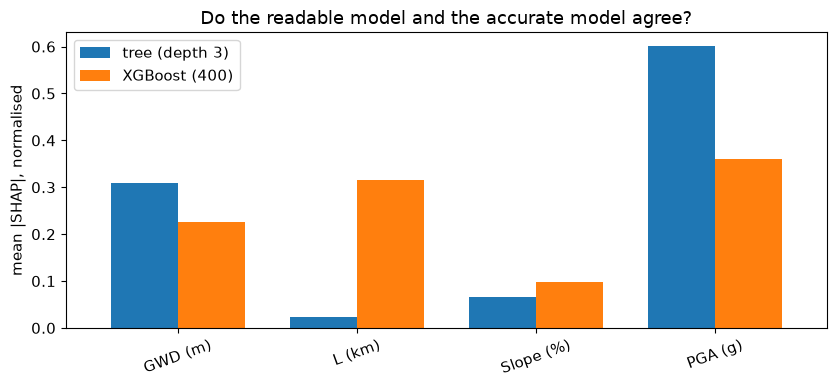

           tree (depth 3)  XGBoost (400)
GWD (m)             0.309          0.225
L (km)              0.024          0.316
Slope (%)           0.067          0.098
PGA (g)             0.600          0.361


In [17]:
dt_expl = shap.TreeExplainer(dt)
dt_sv = dt_expl(X_test)


def mean_abs_shap(sv):
    """Mean |SHAP| per feature, tolerating the per-class axis.

    A binary sklearn classifier returns values of shape
    (n_rows, n_features, n_classes) -- one attribution per class. Binary
    XGBoost returns (n_rows, n_features), because it models a single
    log-odds output. Take the positive class when the axis is present so
    the two models are compared on the same quantity.
    """
    v = sv.values
    if v.ndim == 3:
        v = v[:, :, 1]
    return np.abs(v).mean(0)


print(f"decision tree SHAP shape : {dt_sv.values.shape}")
print(f"XGBoost SHAP shape       : {shap_values.values.shape}")

cmp = pd.DataFrame({
    "tree (depth 3)": mean_abs_shap(dt_sv),
    "XGBoost (400)": mean_abs_shap(shap_values),
}, index=features)
cmp = cmp / cmp.sum()

ax = cmp.plot.bar(figsize=(8.5, 4), rot=20, width=.75)
ax.set_ylabel("mean |SHAP|, normalised")
ax.set_title("Do the readable model and the accurate model agree?")
plt.tight_layout(); plt.show()
print(cmp.to_string(float_format="{:.3f}".format))

### The test set, touched once, gives the honest score

We have touched the test set exactly once so far. Here is the honest final
score.

              precision    recall  f1-score   support

no spreading      0.792     0.874     0.831       636
   spreading      0.796     0.681     0.734       458

    accuracy                          0.793      1094
   macro avg      0.794     0.778     0.783      1094
weighted avg      0.794     0.793     0.790      1094



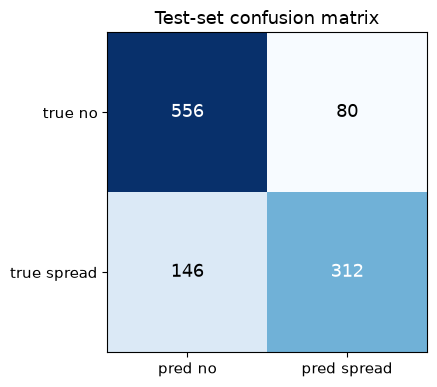

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, xgb.predict(X_test),
                            target_names=["no spreading", "spreading"], digits=3))

cm = confusion_matrix(y_test, xgb.predict(X_test))
fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(cm, cmap="Blues")
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, str(v), ha="center", va="center",
            color="white" if v > cm.max() / 2 else "black", fontsize=13)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=["pred no", "pred spread"],
       yticklabels=["true no", "true spread"], title="Test-set confusion matrix")
plt.tight_layout(); plt.show()

In a hazard setting the two off-diagonal cells are not equally bad. A
false negative is a site you declared safe that spreads; a false positive is
money spent on ground improvement you did not need. Which error you tolerate is
an engineering decision, not a modelling one — you tune it by moving the
probability threshold away from 0.5, not by changing the model.

## Summary

| | |
| --- | --- |
| **Interpretability is a spectrum** | A depth-3 tree explains itself. A 400-tree ensemble does not. You choose where to sit. |
| **"Feature importance" is not one number** | Weight, gain, and permutation agreed on the ranking here but differed 5-6x on slope's magnitude. Say which one you used. |
| **A gain/permutation gap means redundancy** | The model *used* slope but did not *need* it. That is a fact about the feature set, not about the physics. |
| **Global importance answers the wrong question** | Engineers assess *sites*, not datasets. SHAP attributes individual predictions. |
| **SHAP is uniquely principled** | Efficiency, symmetry, and dummy pin it down to one answer, and we verified efficiency numerically. |
| **The real payoff is catching bad models** | A physically backwards SHAP direction is a bug you would otherwise have shipped. |

### Physics in the model beats interrogating it afterwards

Module 2 traded three interpretable exponents for a few thousand opaque weights.
SHAP is how you buy the interpretation back after the fact.

Note what it is *not*: SHAP tells you what the **model** did, not what the
**ground** does. It is a statement about a function fitted to 7,291 observations.
Correlation in the training data becomes attribution in the explanation.

Which is why the next two modules take the opposite route. Instead of fitting a
flexible model and interrogating it afterwards, we build the physics into the
model itself — so that it cannot learn a relationship that violates the
governing equations in the first place.

### Go deeper

- [Full XAI training notebook](https://github.com/DesignSafe-Training/xai) — the
  longer version of this module, with the Gini derivations worked out
- [SciML — classification and decision trees](https://kks32-courses.github.io/sciml/00-mlp/00a-classification.html)
- Lundberg & Lee (2017), *A Unified Approach to Interpreting Model Predictions* —
  the SHAP paper
- Molnar, [*Interpretable Machine Learning*](https://christophm.github.io/interpretable-ml-book/) — the standard free reference